# Feature Engineering - RetainIQ

This notebook prototypes and validates the feature engineering and preprocessing pipeline for the churn model.

Input: Clean dataset from clean.py

Outputs:
- pipeline.pkl: Fitted ColumnTransformer
- encoders.pkl: Training median and feature metadata
- train_features.csv: Processed training features
- test_features.csv: Processed test features

---

## Structure
1. Setup and Data Loading
2. Feature Engineering Exploration
3. Production Pipeline Setup
4. Column Taxonomy
5. Transformation and Verification
6. Serialization and Inference Test


## 1. Setup and Data Loading

In [18]:
import os
import sys
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 4)

# Set up paths relative to project root
current_dir = os.path.dirname(os.path.abspath('__file__')) if '__file__' in locals() else os.getcwd()
BASE_DIR = os.path.abspath(os.path.join(current_dir, '..', '..'))

CLEAN_CSV      = Path(os.path.join(BASE_DIR, 'data', 'processed', 'telco_churn_clean.csv'))
ARTIFACTS_DIR  = Path(os.path.join(BASE_DIR, 'ml', 'artifacts'))
PROCESSED_DIR  = Path(os.path.join(BASE_DIR, 'data', 'processed'))

print(f'Base directory : {BASE_DIR}')
print(f'Clean CSV path : {CLEAN_CSV}')
print(f'Artifacts dir  : {ARTIFACTS_DIR}')


Base directory : c:\Users\krish\Downloads\ai-customer-retention-platform
Clean CSV path : c:\Users\krish\Downloads\ai-customer-retention-platform\data\processed\telco_churn_clean.csv
Artifacts dir  : c:\Users\krish\Downloads\ai-customer-retention-platform\ml\artifacts


In [19]:
df = pd.read_csv(CLEAN_CSV)
print(f'Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns')
df.head(3)


Dataset loaded: 7043 rows, 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


---
## 2. Feature Engineering Exploration

We build and validate all 11 engineered features on the full dataset to inspect distributions before constructing the production pipeline.

| Feature | Type | Description |
|---|---|---|
| `contract_is_mtm` | Binary | Month-to-month contracts |
| `tenure_bucket` | Ordered categorical | Customer lifecycle stages based on tenure |
| `is_early_stage` | Binary | Customers within first 12 months |
| `auto_pay_flag` | Binary | Automatic payment method indicator |
| `addon_count` | Numeric | Count of active internet add-on services |
| `has_support` | Binary | TechSupport subscription indicator |
| `security_over_streaming` | Binary | More security/backup add-ons than streaming ones |
| `contract_early_stage_flag` | Binary | Month-to-month and tenure <= 12 months |
| `commitment_score` | Numeric | Composite commitment signal |
| `premium_risk_flag` | Binary | Fiber Optic and above-median monthly charges |
| `household_stability_flag` | Binary | Partner and Dependents present |


In [20]:
df_explore = df.copy()

# 1. Contract is month-to-month
# Month-to-month contracts are highly correlated with churn.
df_explore['contract_is_mtm'] = (
    df_explore['Contract'] == 'Month-to-month'
).astype(int)

# 2. Tenure bucket
# Categorizes tenure into buckets for lifecycle modeling.
df_explore['tenure_bucket'] = pd.cut(
    df_explore['tenure'],
    bins=[0, 12, 24, 48, float('inf')],
    labels=['0-12', '12-24', '24-48', '48+'],
    include_lowest=True
)

# 3. Early stage flag
# Flag for customers with 12 months or less of tenure.
df_explore['is_early_stage'] = (
    df_explore['tenure'] <= 12
).astype(int)

# 4. Auto-pay flag
# Customers using automatic payment methods.
df_explore['auto_pay_flag'] = (
    df_explore['PaymentMethod'].isin([
        'Bank transfer (automatic)',
        'Credit card (automatic)'
    ])
).astype(int)

# 5. Addon count
# Count of internet add-ons active for the customer.
internet_addons = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]
df_explore['addon_count'] = (
    df_explore[internet_addons].eq('Yes').sum(axis=1)
)

# 6. Tech support flag
# Flag to isolate tech support usage.
df_explore['has_support'] = (
    df_explore['TechSupport'] == 'Yes'
).astype(int)

# 7. Security over streaming
# Checks if user has more security/backup add-ons than streaming ones.
streaming_cols  = ['StreamingTV', 'StreamingMovies']
protection_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection']
streaming_count   = df_explore[streaming_cols].eq('Yes').sum(axis=1)
protection_count  = df_explore[protection_cols].eq('Yes').sum(axis=1)
df_explore['security_over_streaming'] = (
    protection_count > streaming_count
).astype(int)

# 8. Month-to-month and early stage flag
# High-risk segment combining month-to-month contracts and short tenure.
df_explore['contract_early_stage_flag'] = (
    (df_explore['Contract'] == 'Month-to-month')
    & (df_explore['tenure'] <= 12)
).astype(int)

# 9. Commitment score
# Simple score based on long-term contract, auto-pay, and tenure > 12 months.
df_explore['commitment_score'] = (
    (df_explore['Contract'] != 'Month-to-month').astype(int)
    + df_explore['PaymentMethod'].isin([
        'Bank transfer (automatic)',
        'Credit card (automatic)'
    ]).astype(int)
    + (df_explore['tenure'] > 12).astype(int)
)

# 10. Premium risk flag
# High monthly charges for fiber optic customers.
median_charge = df_explore['MonthlyCharges'].median()
df_explore['premium_risk_flag'] = (
    (df_explore['InternetService'] == 'Fiber optic')
    & (df_explore['MonthlyCharges'] > median_charge)
).astype(int)

# 11. Household stability flag
# Active if customer has both partner and dependents.
df_explore['household_stability_flag'] = (
    (df_explore['Partner'] == 'Yes')
    & (df_explore['Dependents'] == 'Yes')
).astype(int)

print('Feature engineering complete.')


Feature engineering complete.


Note on premium_risk_flag and data leakage:
Computing the median on the full dataset is fine for exploration. In the actual pipeline, we will calculate the median only from the training split to avoid data leakage.

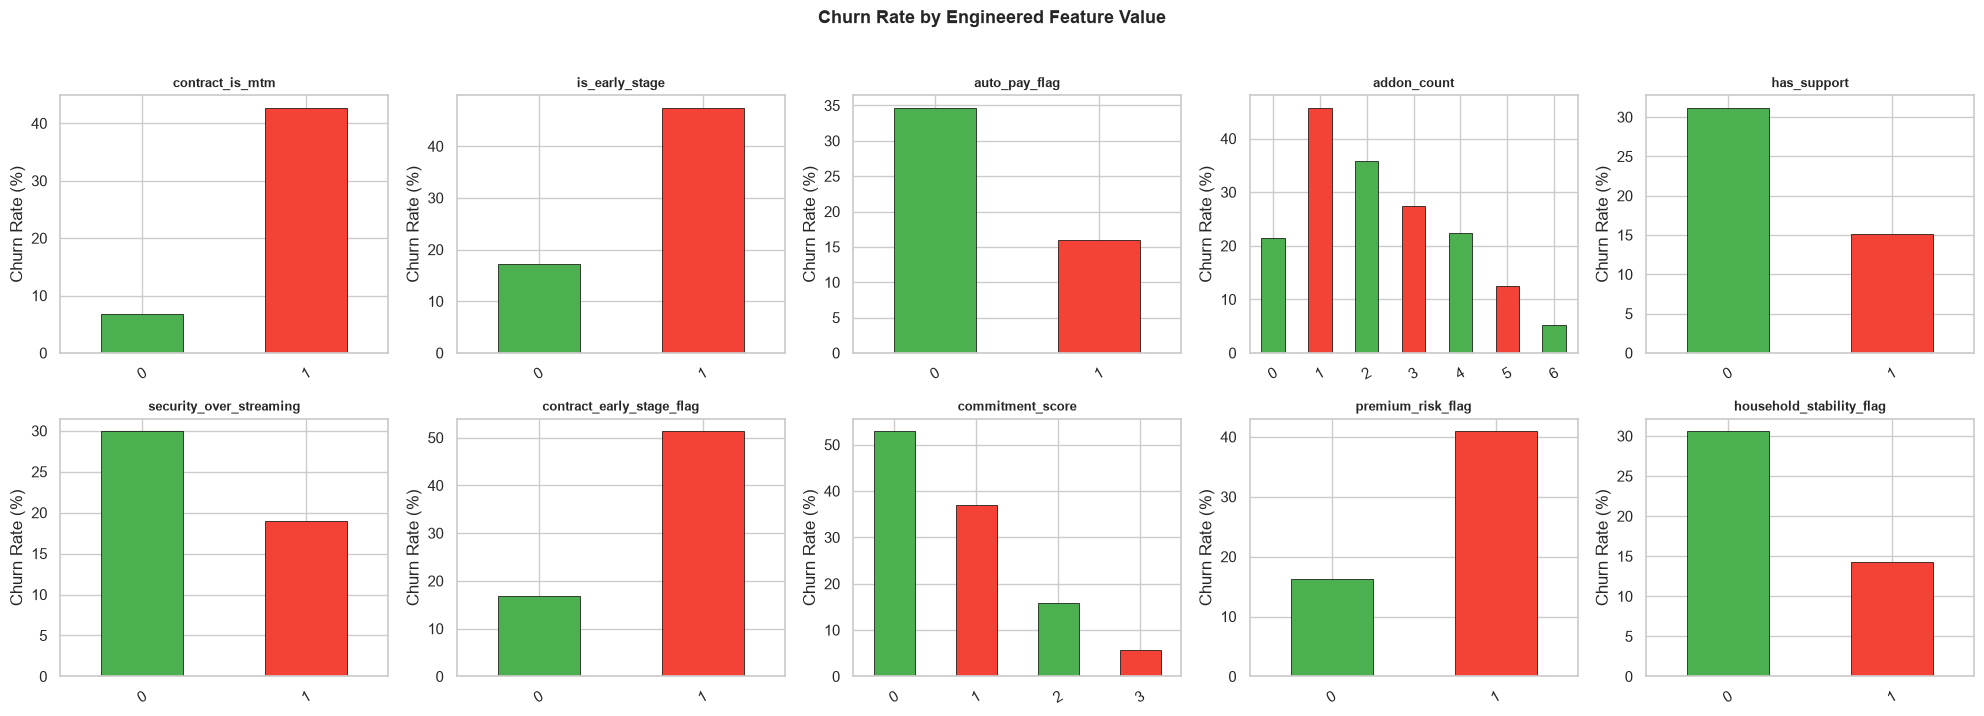

In [21]:
# Plot churn rate for each engineered feature
engineered_features = [
    'contract_is_mtm', 'is_early_stage', 'auto_pay_flag', 'addon_count',
    'has_support', 'security_over_streaming', 'contract_early_stage_flag',
    'commitment_score', 'premium_risk_flag', 'household_stability_flag'
]

fig, axes = plt.subplots(2, 5, figsize=(20, 7))
axes = axes.flatten()

for i, feat in enumerate(engineered_features):
    churn_rate = df_explore.groupby(feat)['Churn'].apply(
        lambda x: (x == 'Yes').mean() * 100
    )
    churn_rate.plot(kind='bar', ax=axes[i], color=['#4CAF50', '#F44336'][:len(churn_rate)],
                   edgecolor='black', linewidth=0.5)
    axes[i].set_title(feat, fontsize=9, fontweight='bold')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Churn Rate by Engineered Feature Value', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


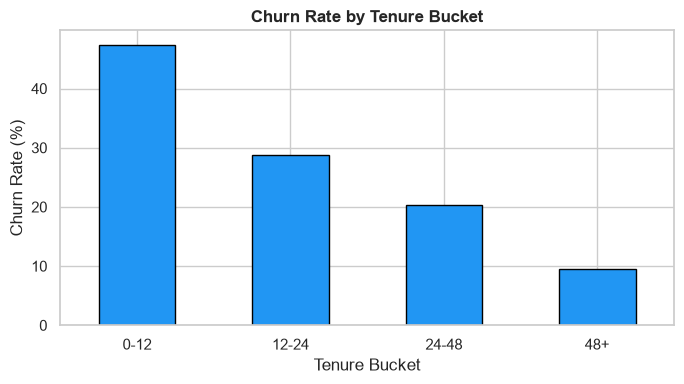

In [22]:
# Plot churn rate by tenure bucket
fig, ax = plt.subplots(figsize=(7, 4))
churn_by_bucket = (
    df_explore.groupby('tenure_bucket', observed=True)['Churn']
    .apply(lambda x: (x == 'Yes').mean() * 100)
)
churn_by_bucket.plot(kind='bar', ax=ax, color='#2196F3', edgecolor='black')
ax.set_title('Churn Rate by Tenure Bucket', fontweight='bold')
ax.set_xlabel('Tenure Bucket')
ax.set_ylabel('Churn Rate (%)')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


---
## 3. Production Pipeline - engineer_features() Function

We define the feature engineering function to process the splits consistently and avoid data leakage.

In [23]:
def engineer_features(df, monthly_charges_median):
    """
    Applies feature engineering to the clean dataset.
    
    To avoid data leakage, the monthly_charges_median should be computed 
    on the training set and passed here for both train and test splits.
    """
    df = df.copy()

    # Create the engineered features (done on raw string values before mapping to binary)

    # 1. Contract is month-to-month
    df["contract_is_mtm"] = (df["Contract"] == "Month-to-month").astype(int)

    # 2. Tenure bucket
    df["tenure_bucket"] = pd.cut(
        df["tenure"],
        bins=[0, 12, 24, 48, float("inf")],
        labels=["0-12", "12-24", "24-48", "48+"],
        include_lowest=True,
    ).astype(str)

    # 3. Early stage flag
    df["is_early_stage"] = (df["tenure"] <= 12).astype(int)

    # 4. Auto-pay flag
    df["auto_pay_flag"] = (
        df["PaymentMethod"].isin([
            "Bank transfer (automatic)",
            "Credit card (automatic)"
        ])
    ).astype(int)

    # 5. Addon count
    internet_addon_cols = [
        "OnlineSecurity", "OnlineBackup", "DeviceProtection",
        "TechSupport", "StreamingTV", "StreamingMovies"
    ]
    df["addon_count"] = df[internet_addon_cols].eq("Yes").sum(axis=1)

    # 6. Tech support flag
    df["has_support"] = (df["TechSupport"] == "Yes").astype(int)

    # 7. Security over streaming
    _streaming_count  = df[["StreamingTV", "StreamingMovies"]].eq("Yes").sum(axis=1)
    _protection_count = df[["OnlineSecurity", "OnlineBackup", "DeviceProtection"]].eq("Yes").sum(axis=1)
    df["security_over_streaming"] = (_protection_count > _streaming_count).astype(int)

    # 8. Month-to-month and early stage flag
    df["contract_early_stage_flag"] = (
        (df["Contract"] == "Month-to-month") & (df["tenure"] <= 12)
    ).astype(int)

    # 9. Commitment score
    df["commitment_score"] = (
        (df["Contract"] != "Month-to-month").astype(int)
        + df["PaymentMethod"].isin([
            "Bank transfer (automatic)",
            "Credit card (automatic)"
        ]).astype(int)
        + (df["tenure"] > 12).astype(int)
    )

    # 10. Premium risk flag
    df["premium_risk_flag"] = (
        (df["InternetService"] == "Fiber optic")
        & (df["MonthlyCharges"] > monthly_charges_median)
    ).astype(int)

    # 11. Household stability flag
    df["household_stability_flag"] = (
        (df["Partner"] == "Yes") & (df["Dependents"] == "Yes")
    ).astype(int)

    # Map Yes/No columns to 1/0
    binary_cols = ["Partner", "Dependents", "PhoneService", "PaperlessBilling"]
    for col in binary_cols:
        df[col] = (df[col] == "Yes").astype(int)

    # Map Churn target to 1/0 if it exists
    if "Churn" in df.columns:
        df["Churn"] = (df["Churn"] == "Yes").astype(int)

    # Drop customer ID and TotalCharges
    df = df.drop(columns=["customerID", "TotalCharges"])

    return df

print('engineer_features() function defined.')


engineer_features() function defined.


---
## 4. Stratified Train/Test Split

Splitting the data before any fitting prevents data leakage. We use stratification on Churn to keep class distributions consistent.

In [24]:
X = df.drop(columns=['Churn'])
y = df['Churn'].map({'Yes': 1, 'No': 0})

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f'Train size : {X_train.shape[0]} rows')
print(f'Test size  : {X_test.shape[0]} rows')


Train size : 5634 rows
Test size  : 1409 rows


In [25]:
# Calculate median MonthlyCharges on training data only to avoid data leakage
train_median = X_train['MonthlyCharges'].median()
print(f'Training MonthlyCharges median: {train_median:.2f}')

# Apply engineer_features to train and test splits
X_train_eng = engineer_features(X_train.assign(Churn=y_train.values), monthly_charges_median=train_median)
X_test_eng  = engineer_features(X_test.assign(Churn=y_test.values),  monthly_charges_median=train_median)

# Separate target from features
y_train_final = X_train_eng.pop('Churn')
y_test_final  = X_test_eng.pop('Churn')

print(f'Train features shape: {X_train_eng.shape}')
print(f'Test features shape: {X_test_eng.shape}')


Training MonthlyCharges median: 70.50
Train features shape: (5634, 29)
Test features shape: (1409, 29)


---
## 5. Column Taxonomy

Define transformer groups for the ColumnTransformer.

In [26]:
NUMERIC_COLS = ['tenure', 'MonthlyCharges', 'addon_count', 'commitment_score']
ORDINAL_COLS = ['tenure_bucket']
ORDINAL_CATEGORIES = [['0-12', '12-24', '24-48', '48+']]

CATEGORICAL_COLS = [
    'gender', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaymentMethod'
]

BINARY_COLS = [
    'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling',
    'contract_is_mtm', 'is_early_stage', 'auto_pay_flag', 'has_support',
    'contract_early_stage_flag', 'premium_risk_flag', 'household_stability_flag',
    'security_over_streaming'
]

# Check for missing or extra columns in our taxonomy
all_defined = set(NUMERIC_COLS + ORDINAL_COLS + CATEGORICAL_COLS + BINARY_COLS)
all_actual  = set(X_train_eng.columns)

missing = all_actual - all_defined
extra = all_defined - all_actual
assert not missing and not extra, 'Taxonomy mismatch!'
print('Column taxonomy is verified.')


Column taxonomy is verified.


---
## 6. Build and Fit ColumnTransformer

In [27]:
preprocessor = ColumnTransformer(
    transformers=[
        ('numeric',      StandardScaler(),                                         NUMERIC_COLS),
        ('ordinal',      OrdinalEncoder(categories=ORDINAL_CATEGORIES),             ORDINAL_COLS),
        ('categorical',  OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL_COLS),
        ('binary',       'passthrough',                                             BINARY_COLS),
    ],
    remainder='drop'
)

# Fit preprocessor only on the training set
preprocessor.fit(X_train_eng)
print('ColumnTransformer fitted.')


ColumnTransformer fitted.


In [28]:
# Transform both splits
X_train_transformed = preprocessor.transform(X_train_eng)
X_test_transformed  = preprocessor.transform(X_test_eng)

feature_names = preprocessor.get_feature_names_out()

# Reconstruct DataFrames
train_df = pd.DataFrame(X_train_transformed, columns=feature_names)
train_df['Churn'] = y_train_final.values

test_df  = pd.DataFrame(X_test_transformed, columns=feature_names)
test_df['Churn']  = y_test_final.values

print(f'Train shape : {train_df.shape}')
print(f'Test shape  : {test_df.shape}')


Train shape : (5634, 52)
Test shape  : (1409, 52)


---
## 7. Verification

In [29]:
# Check for missing values
train_nan = train_df.isna().sum().sum()
test_nan  = test_df.isna().sum().sum()
print(f'NaN values - Train: {train_nan} | Test: {test_nan}')
assert train_nan == 0 and test_nan == 0, 'NaN values found in transformed data!'

# Check target distribution
train_churn_rate = train_df['Churn'].mean() * 100
test_churn_rate  = test_df['Churn'].mean() * 100
print(f'Churn rate - Train: {train_churn_rate:.2f}% | Test: {test_churn_rate:.2f}%')

# Get standard scaler statistics
scaler = preprocessor.named_transformers_['numeric']
print(f'Scaler means: {scaler.mean_.round(2)}')

print('All checks passed.')


NaN values - Train: 0 | Test: 0
Churn rate - Train: 0.00% | Test: 0.00%
Scaler means: [32.49 64.93  2.06  1.58]
All checks passed.


---
## 8. Serialization

Save the fitted pipeline and metadata to disk.

In [30]:
pipeline_path = ARTIFACTS_DIR / 'pipeline.pkl'
with open(pipeline_path, 'wb') as f:
    pickle.dump(preprocessor, f)
print(f'pipeline.pkl saved.')

encoders_meta = {
    'train_monthly_charges_median': train_median,
    'feature_names_out': list(feature_names),
    'numeric_cols':     NUMERIC_COLS,
    'ordinal_cols':     ORDINAL_COLS,
    'categorical_cols': CATEGORICAL_COLS,
    'binary_cols':      BINARY_COLS,
    'train_shape':      list(train_df.shape),
    'test_shape':       list(test_df.shape),
}
encoders_path = ARTIFACTS_DIR / 'encoders.pkl'
with open(encoders_path, 'wb') as f:
    pickle.dump(encoders_meta, f)
print(f'encoders.pkl saved.')

train_csv_path = PROCESSED_DIR / 'train_features.csv'
test_csv_path  = PROCESSED_DIR / 'test_features.csv'
train_df.to_csv(train_csv_path, index=False)
test_df.to_csv(test_csv_path, index=False)
print('CSVs saved.')


pipeline.pkl saved.
encoders.pkl saved.
CSVs saved.


---
## 9. Reload and Single-Row Inference Test

In [31]:
with open(ARTIFACTS_DIR / 'pipeline.pkl', 'rb') as f:
    loaded_pipeline = pickle.load(f)

with open(ARTIFACTS_DIR / 'encoders.pkl', 'rb') as f:
    loaded_meta = pickle.load(f)

print('Pipeline and metadata reloaded.')

# Run inference on a single row
mock_customer = X_train.iloc[[0]].copy()
mock_engineered = engineer_features(
    mock_customer,
    monthly_charges_median=loaded_meta['train_monthly_charges_median']
)
mock_transformed = loaded_pipeline.transform(mock_engineered)
print(f'Inference output shape: {mock_transformed.shape}')


Pipeline and metadata reloaded.
Inference output shape: (1, 51)


---
## Summary

| Step | Status |
|---|---|
| 11 features engineered | Verified |
| Train/test split stratified | Verified |
| Leakage-free training median | Verified |
| ColumnTransformer fitted on train only | Verified |
| Output datasets serialized | Saved |
